# Real-Time Emotion Detection

# Model Evaluation

## Objectives

- Load the trained CNN model
- Evaluate on the test dataset
- Generate Confusion Matrix
- Display Classification Report

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [10]:
IMAGE_SIZE = (48, 48)
BATCH_SIZE = 32

In [11]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False
)

class_names = test_dataset.class_names

Found 7178 files belonging to 7 classes.


In [12]:
normalization_layer = tf.keras.layers.Rescaling(1. / 255)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [13]:
model = tf.keras.models.load_model("../models/emotion_model.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [14]:
predictions = model.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)

225/225 [==============================] - 10s 45ms/step


In [15]:
true_labels = np.concatenate(
    [labels for images, labels in test_dataset],
    axis=0
)

<Figure size 800x800 with 0 Axes>

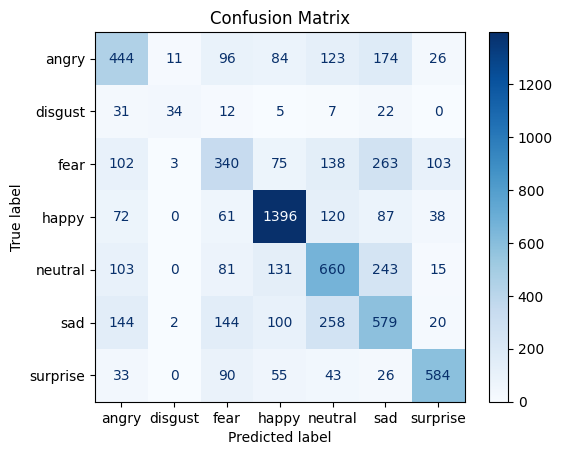

In [16]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8,8))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [17]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       angry       0.48      0.46      0.47       958
     disgust       0.68      0.31      0.42       111
        fear       0.41      0.33      0.37      1024
       happy       0.76      0.79      0.77      1774
     neutral       0.49      0.54      0.51      1233
         sad       0.42      0.46      0.44      1247
    surprise       0.74      0.70      0.72       831

    accuracy                           0.56      7178
   macro avg       0.57      0.51      0.53      7178
weighted avg       0.56      0.56      0.56      7178



# Evaluation Summary

Completed:

- Loaded trained CNN model
- Generated predictions
- Displayed Confusion Matrix
- Displayed Classification Report